In [2]:
import os
from pathlib import Path

import pandas as pd

## Read aggregate ResStock Result File

In [3]:
current_path = Path(os.getcwd())
results_folder = current_path / ".." / "results"
resstock = results_folder / "aggregated_load_nodes_wide_resstock_res_only_resstock_filled_ami.xlsx"
df_resstock = pd.read_excel(resstock)

print("\df_resstock:")
print(df_resstock.head())


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/654283500.py:6: SyntaxWarning: invalid escape sequence '\d'
  print("\df_resstock:")


\df_resstock:
          ENDTIME_EST  220268180_RES  220268181_RES  220268182_RES  \
0 2024-01-01 00:00:00       0.281185       0.147639            0.0   
1 2024-01-01 00:15:00       0.000000       0.000000            0.0   
2 2024-01-01 00:30:00       0.150365       0.146244            0.0   
3 2024-01-01 00:45:00       0.150607       0.145657            0.0   
4 2024-01-01 01:00:00       0.150454       0.144834            0.0   

   220268183_RES  220268184_RES  220268252_RES  220268260_RES  220268261_RES  \
0       1.171721            0.0       0.199639       1.630825       0.266444   
1       0.000000            0.0       0.000000       0.000000       0.000000   
2       0.881496            0.0       0.184586       0.940588       0.256530   
3       0.866862            0.0       0.183921       1.309210       0.256162   
4       0.854678            0.0       0.183759       1.567410       0.255128   

   220269721_RES  ...  220603575_RES  310007575_RES  310059674_RES  \
0            0

## Read Node File

In [4]:
node_1 = results_folder / "branch_1_spot_loads.csv"
node_2 = results_folder / "branch_2_spot_loads.csv"

df_node_1 = pd.read_csv(node_1)
df_node_2 = pd.read_csv(node_2)

print("\df_node_1:")
print(df_node_1.head())

print("\df_node_2:")
print(df_node_2.head())

\df_node_1:
   Network Id   Section Id  Spot Number Phase       Spot Type  \
0     4301002  220529452-L    220529452     A     Residential   
1     4301002  220268252-L    220268252     A     Residential   
2     4301002  310038852-L    310038852     A  NonResidential   
3     4301002  220269962-L    220269962     A  NonResidential   
4     4301002  220269963-L    220269963     A     Residential   

   Spot kVA A (kVA)  Spot kVA B (kVA)  Spot kVA C (kVA)  Spot Tot kVA (kVA)  \
0               6.0               0.0               NaN                6.04   
1               3.6               0.0               NaN                3.65   
2              12.0               0.0               NaN               11.96   
3              21.7               0.0               NaN               21.74   
4               5.2               0.0               NaN                5.17   

   Spot PF A (%)  ...  Spot kWh C (kWh)  Spot Tot kWh (kWh)  Spot Cust A  \
0          91.46  ...               NaN       

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/1976595116.py:7: SyntaxWarning: invalid escape sequence '\d'
  print("\df_node_1:")
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/1976595116.py:10: SyntaxWarning: invalid escape sequence '\d'
  print("\df_node_2:")


# READ AMI FILE

In [5]:
ami = results_folder / "aggregated_load_nodes_wide_12102025.csv"
df_ami = pd.read_csv(ami)

print("\df_ami:")
print(df_ami.head())


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/2543178643.py:4: SyntaxWarning: invalid escape sequence '\d'
  print("\df_ami:")


\df_ami:
   ENDTIME_EST  220268180_RES  220268181_RES  220268182_RES  220268183_NRS  \
0  1/1/24 0:00          0.225          0.187            0.0            0.0   
1  1/1/24 0:15          0.217          0.123            0.0            0.0   
2  1/1/24 0:30          0.246          0.145            0.0            0.0   
3  1/1/24 0:45          0.196          0.164            0.0            0.0   
4  1/1/24 1:00          0.234          0.127            0.0            0.0   

   220268183_RES  220268184_RES  220268252_RES  220268260_NRS  220268260_RES  \
0          0.356            0.0          0.140            0.0          0.925   
1          0.446            0.0          0.198            0.0          2.041   
2          0.472            0.0          0.186            0.0          2.441   
3          0.778            0.0          0.118            0.0          1.644   
4          0.218            0.0          0.109            0.0          0.940   

   ...  310038852_NRS  310059674_RES  310

In [6]:
spot_1 = []
spot_2 = []
spot_1 = df_node_1['Spot Number']
spot_2 = df_node_2['Spot Number']

print(spot_1)

0     220529452
1     220268252
2     310038852
3     220269962
4     220269963
5     220450981
6     220269968
7     220269967
8     220269966
9     220269965
10    312170331
Name: Spot Number, dtype: int64


# SPOT 1

In [7]:
# Find and aggregate resstock loads for spot 1


TS_COL = "ENDTIME_EST"

spot_1_ids = set(spot_1.astype(str))

# ResStock columns for spot_1
res_cols_1 = [
    c for c in df_resstock.columns
    if c != TS_COL and c.split("_")[0] in spot_1_ids
]

# Aggregate ResStock
res_agg_1 = df_resstock[[TS_COL]].copy()
res_agg_1["res_agg_1"] = df_resstock[res_cols_1].sum(axis=1)

print(res_agg_1.head())

print("Number of spot_1 IDs:", len(spot_1_ids))
print("Number of matched df_resstock columns:", len(res_cols_1))

matched_ids = {c.split("_")[0] for c in res_cols_1}
missing_ids = spot_1_ids - matched_ids

print("\nMissing building IDs (in spot_1 but not in df_resstock):")
print(sorted(missing_ids))

          ENDTIME_EST  res_agg_1
0 2024-01-01 00:00:00   4.219903
1 2024-01-01 00:15:00   0.000000
2 2024-01-01 00:30:00   3.807416
3 2024-01-01 00:45:00   3.798921
4 2024-01-01 01:00:00   3.754375
Number of spot_1 IDs: 11
Number of matched df_resstock columns: 8

Missing building IDs (in spot_1 but not in df_resstock):
['220269962', '220450981', '310038852']


In [8]:
## RESSTOCK AGGREGATION
import pandas as pd

TS_COL = "ENDTIME_EST"

# ============================
# Spot 1: ResStock + AMI fallback
# ============================
SPOT_NAME = "spot_1"
OUT_COL   = "res_agg_1"

# --- 0) FORCE SAME DATETIME TYPE IN BOTH DFS ---
df_resstock[TS_COL] = pd.to_datetime(df_resstock[TS_COL], errors="coerce")
df_ami[TS_COL]      = pd.to_datetime(df_ami[TS_COL], errors="coerce")
df_resstock = df_resstock.dropna(subset=[TS_COL])
df_ami      = df_ami.dropna(subset=[TS_COL])

# --- 1) SPOT 1 IDS ---
spot_1_ids = sorted({str(x) for x in spot_1.dropna().unique()})

# --- 2) RESSTOCK: IDs available + columns to use ---
res_ids_available = {c.split("_")[0] for c in df_resstock.columns if c != TS_COL}
ids_from_resstock = sorted([bid for bid in spot_1_ids if bid in res_ids_available])
ids_missing_res   = sorted([bid for bid in spot_1_ids if bid not in res_ids_available])

res_cols_1 = [
    c for c in df_resstock.columns
    if c != TS_COL and c.split("_")[0] in ids_from_resstock
]

# --- 3) AMI: columns to use for missing IDs (match by bid prefix) ---
ami_cols_for_missing = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in ids_missing_res
]
ids_from_ami = sorted({c.split("_")[0] for c in ami_cols_for_missing})

# IDs missing in both (drop)
ids_missing_both = sorted(set(ids_missing_res) - set(ids_from_ami))
spot_1_ids_used  = sorted(set(spot_1_ids) - set(ids_missing_both))

# --- 4) PRINTS ---
print(f"\n{SPOT_NAME} IDs used (after removing missing-in-both IDs):")
print(spot_1_ids_used)

print("\nIDs pulled from ResStock:")
print(ids_from_resstock)

print("\nIDs pulled from AMI (fallback for missing ResStock):")
print(ids_from_ami)

print("\nIDs missing in BOTH ResStock and AMI (dropped):")
print(ids_missing_both)

print("\n--- FINAL SOURCE SUMMARY ---")
for bid in spot_1_ids_used:
    print(f"{bid}: {'ResStock' if bid in ids_from_resstock else 'AMI fallback'}")

# --- 5) AGGREGATE RESSTOCK + AMI FALLBACK ---
res_part = df_resstock[[TS_COL]].copy()
res_part["res_sum"] = df_resstock[res_cols_1].sum(axis=1) if len(res_cols_1) else 0.0

ami_part = df_ami[[TS_COL]].copy()
ami_part["ami_fallback_sum"] = df_ami[ami_cols_for_missing].sum(axis=1) if len(ami_cols_for_missing) else 0.0

res_agg_1 = res_part.merge(ami_part, on=TS_COL, how="left")
res_agg_1["ami_fallback_sum"] = res_agg_1["ami_fallback_sum"].fillna(0.0)
res_agg_1[OUT_COL] = res_agg_1["res_sum"] + res_agg_1["ami_fallback_sum"]
res_agg_1 = res_agg_1[[TS_COL, OUT_COL]]

print("\nres_agg_1.head():")
print(res_agg_1.head())

print("\nAMI columns used for fallback:")
print(ami_cols_for_missing)


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/1680874831.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ami[TS_COL]      = pd.to_datetime(df_ami[TS_COL], errors="coerce")



spot_1 IDs used (after removing missing-in-both IDs):
['220268252', '220269962', '220269963', '220269965', '220269966', '220269967', '220269968', '220529452', '310038852', '312170331']

IDs pulled from ResStock:
['220268252', '220269963', '220269965', '220269966', '220269967', '220269968', '220529452', '312170331']

IDs pulled from AMI (fallback for missing ResStock):
['220269962', '310038852']

IDs missing in BOTH ResStock and AMI (dropped):
['220450981']

--- FINAL SOURCE SUMMARY ---
220268252: ResStock
220269962: AMI fallback
220269963: ResStock
220269965: ResStock
220269966: ResStock
220269967: ResStock
220269968: ResStock
220529452: ResStock
310038852: AMI fallback
312170331: ResStock

res_agg_1.head():
          ENDTIME_EST  res_agg_1
0 2024-01-01 00:00:00   6.307903
1 2024-01-01 00:15:00   2.741000
2 2024-01-01 00:30:00   5.904416
3 2024-01-01 00:45:00   5.873921
4 2024-01-01 01:00:00   6.406375

AMI columns used for fallback:
['220269962_NRS', '310038852_NRS']


In [9]:
# AMI AGGREGATION
import pandas as pd

TS_COL = "ENDTIME_EST"

# ============================
# AMI spot_1: find cols, aggregate, matches/mismatches
# ============================

# 1) Spot 1 IDs as a SET
spot_1 = df_node_1["Spot Number"]          # <-- change if your column name differs
spot_1_ids = set(spot_1.dropna().astype(str))

# 2) AMI columns that belong to spot_1 (match by building-id prefix before "_")
ami_cols_1 = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in spot_1_ids
]

# 3) Aggregate AMI for spot_1
ami_agg_1 = df_ami[[TS_COL]].copy()
ami_agg_1[TS_COL] = pd.to_datetime(ami_agg_1[TS_COL], errors="coerce")
ami_agg_1["ami_agg_1"] = df_ami[ami_cols_1].sum(axis=1) if len(ami_cols_1) else 0.0

print(ami_agg_1.head())

# 4) Lengths + match/mismatch lists
print("Number of spot_1 IDs:", len(spot_1_ids))
print("Number of matched df_ami columns:", len(ami_cols_1))

matched_ids_1 = {c.split("_")[0] for c in ami_cols_1}
missing_ids_1 = spot_1_ids - matched_ids_1

print("\nMatched building IDs (spot_1):")
print(sorted(matched_ids_1))

print("\nMissing building IDs (in spot_1 but not in df_ami):")
print(sorted(missing_ids_1))

# ============================
# Merge with ResStock aggregate (spot_1)
# ============================

res_agg_1 = res_agg_1.copy()
res_agg_1[TS_COL] = pd.to_datetime(res_agg_1[TS_COL], errors="coerce")

spot_1_agg = (
    res_agg_1.merge(ami_agg_1[[TS_COL, "ami_agg_1"]], on=TS_COL, how="inner")
             .sort_values(TS_COL)
)

print("\nspot_1_agg head():")
print(spot_1_agg.head())
print("Aligned rows:", len(spot_1_agg))


          ENDTIME_EST  ami_agg_1
0 2024-01-01 00:00:00      6.584
1 2024-01-01 00:15:00      6.253
2 2024-01-01 00:30:00      5.843
3 2024-01-01 00:45:00      5.620
4 2024-01-01 01:00:00      7.000
Number of spot_1 IDs: 11
Number of matched df_ami columns: 10

Matched building IDs (spot_1):
['220268252', '220269962', '220269963', '220269965', '220269966', '220269967', '220269968', '220529452', '310038852', '312170331']

Missing building IDs (in spot_1 but not in df_ami):
['220450981']

spot_1_agg head():
          ENDTIME_EST  res_agg_1  ami_agg_1
0 2024-01-01 00:00:00   6.307903      6.584
1 2024-01-01 00:15:00   2.741000      6.253
2 2024-01-01 00:30:00   5.904416      5.843
3 2024-01-01 00:45:00   5.873921      5.620
4 2024-01-01 01:00:00   6.406375      7.000
Aligned rows: 35040


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/535244522.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/535244522.py:75: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/535244522.py:122: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


Saved: /Users/tcharan/Documents/grid_edge_ithaca/grid_edge_fy25/notebooks/figures_resstock_vs_ami/spot_1_A_monthly_profile.png


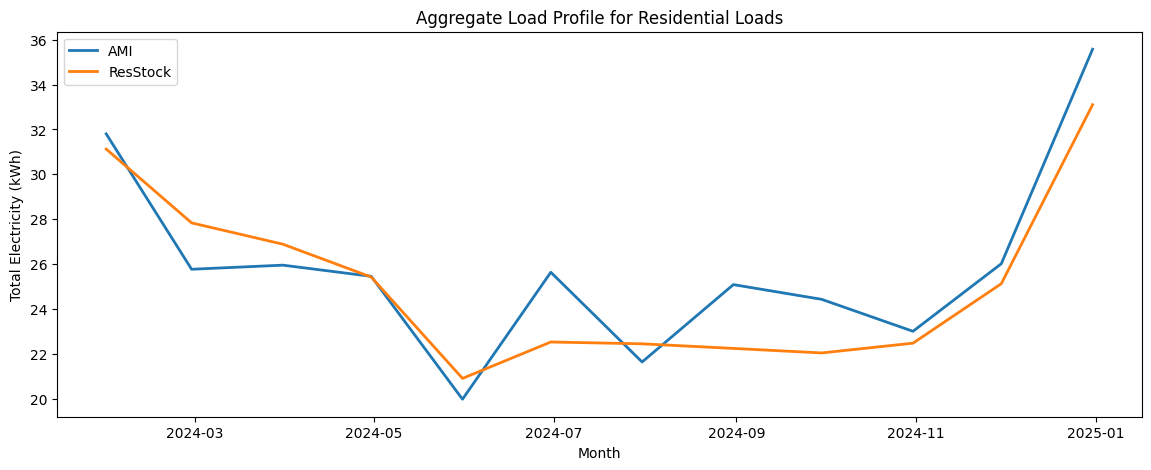

Saved: /Users/tcharan/Documents/grid_edge_ithaca/grid_edge_fy25/notebooks/figures_resstock_vs_ami/spot_1_B_cvrmse_boxplot.png


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/535244522.py:144: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cvrmse_within_month)
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/535244522.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


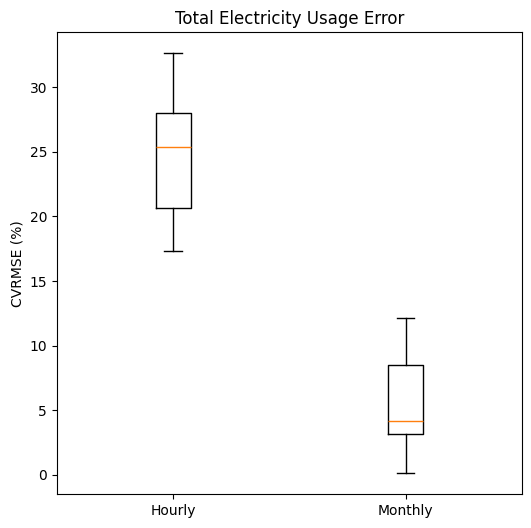

Saved: /Users/tcharan/Documents/grid_edge_ithaca/grid_edge_fy25/notebooks/figures_resstock_vs_ami/spot_1_C_peak_error_boxplot.png


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_52068/535244522.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(peak_data, labels=peak_labels, showfliers=False)


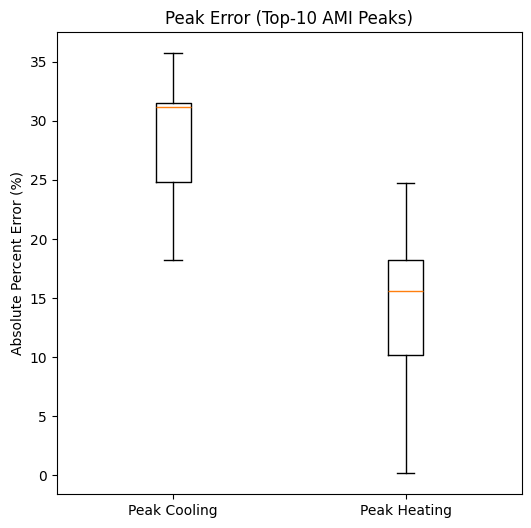

Saved: /Users/tcharan/Documents/grid_edge_ithaca/grid_edge_fy25/notebooks/figures_resstock_vs_ami/spot_1_D_12x24_shape.png


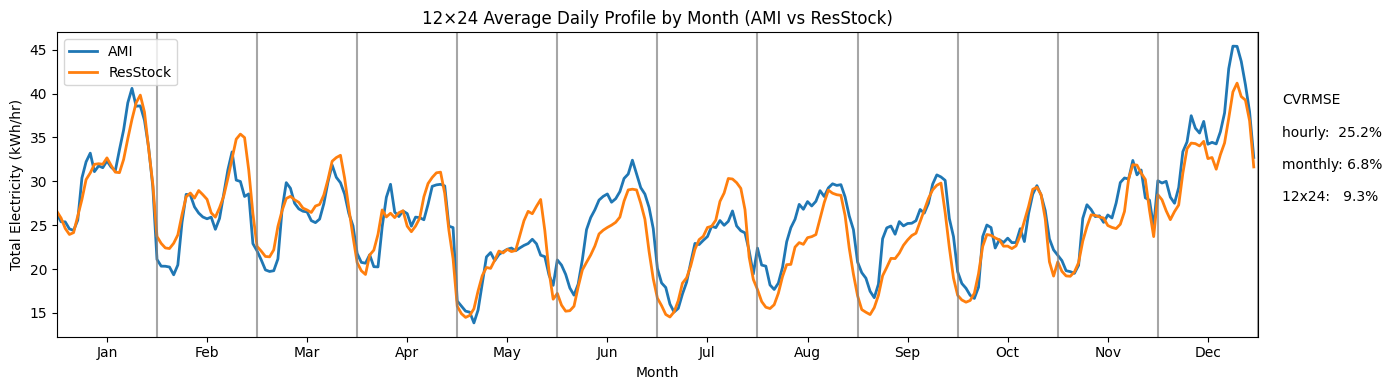


--- Metric Results ---
Hourly CVRMSE: 25.2%
Monthly CVRMSE: 6.8%
12×24 CVRMSE: 9.3%

--- Peak ABS % Error (Top-10) ---
Heating: 14.32%
Cooling: 29.57%


In [10]:
# SPOT 1


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SIMPLE, HUMAN-READABLE AMI vs ResStock METRICS + PLOTS
# - Peaks reported as ABSOLUTE PERCENT ERROR (%)
# - Plot labels: "AMI" and "ResStock"
# - Automatically saves PNGs
# ============================================================

# -----------------------------
# SETTINGS
# -----------------------------
TS_COL = "ENDTIME_EST"
AMI_COL = "ami_agg_1"     # measured
RES_COL = "res_agg_1"     # modeled

TOP_N = 10
EPS = 1e-6
PREFIX = "spot_1"

SEASON_MONTHS = {
    "heating": [1, 2, 3, 4, 11, 12],
    "cooling": [5, 6, 7, 8, 9, 10],
}

# -----------------------------
# OUTPUT DIRECTORY + SAVE HELPER
# -----------------------------
OUTDIR = Path("figures_resstock_vs_ami")
OUTDIR.mkdir(parents=True, exist_ok=True)
current_path = Path(os.getcwd())
results_folder = current_path / ".." / "results"
def save_current_fig(name: str, dpi: int = 300):
    path = results_folder / f"{name}.png"
    plt.gcf().savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path.resolve()}")

# -----------------------------
# 0) Make hourly dataframe
# -----------------------------
df = spot_1_agg[[TS_COL, AMI_COL, RES_COL]].copy()
df[TS_COL] = pd.to_datetime(df[TS_COL])

hourly = (
    df.set_index(TS_COL)[[AMI_COL, RES_COL]]
      .resample("H")
      .sum()
      .reset_index()
)

hourly["month"] = hourly[TS_COL].dt.month
hourly["hod"] = hourly[TS_COL].dt.hour
hourly["error_kwh"] = hourly[RES_COL] - hourly[AMI_COL]
hourly["abs_error_kwh"] = hourly["error_kwh"].abs()
hourly["abs_pct_error"] = (
    np.abs(hourly["error_kwh"]) / np.maximum(hourly[AMI_COL], EPS) * 100
)

# -----------------------------
# 1) CVRMSE
# -----------------------------
def cvrmse(modeled, known, eps=EPS):
    modeled = np.asarray(modeled, dtype=float)
    known = np.asarray(known, dtype=float)
    rmse = np.sqrt(np.mean((modeled - known) ** 2))
    denom = np.mean(known)
    return np.nan if denom <= eps else rmse / denom

hourly_cvrmse = cvrmse(hourly[RES_COL], hourly[AMI_COL]) * 100

monthly_totals = (
    hourly.set_index(TS_COL)[[AMI_COL, RES_COL]]
          .resample("M")
          .sum()
          .reset_index()
)
monthly_cvrmse = cvrmse(monthly_totals[RES_COL], monthly_totals[AMI_COL]) * 100

shape_12x24 = (
    hourly.groupby(["month", "hod"])[[AMI_COL, RES_COL]]
          .mean()
          .reset_index()
          .sort_values(["month", "hod"])
)
cvrmse_12x24 = cvrmse(shape_12x24[RES_COL], shape_12x24[AMI_COL]) * 100

# -----------------------------
# 2) Peak ABS % error (Top-N AMI)
# -----------------------------
def avangrid_peak_top10_abs_pct_error(hourly_df, months, top_n=TOP_N):
    season_df = hourly_df[hourly_df["month"].isin(months)]
    if len(season_df) == 0:
        return np.nan, pd.DataFrame()

    top = season_df.nlargest(top_n, AMI_COL).copy()
    top["abs_pct_error"] = (
        np.abs(top[RES_COL] - top[AMI_COL]) / np.maximum(top[AMI_COL], EPS) * 100
    )

    table = top[[TS_COL, AMI_COL, RES_COL]].copy()
    table["abs_pct_error"] = top["abs_pct_error"]
    table["abs_error_kwh"] = np.abs(top[RES_COL] - top[AMI_COL])

    return float(top["abs_pct_error"].mean()), table

peak_htg_abs_pct, top10_heating_table = avangrid_peak_top10_abs_pct_error(
    hourly, SEASON_MONTHS["heating"]
)
peak_clg_abs_pct, top10_cooling_table = avangrid_peak_top10_abs_pct_error(
    hourly, SEASON_MONTHS["cooling"]
)

# -----------------------------
# 3) PLOTS
# -----------------------------

# A) Monthly aggregate profile
monthly_profile = (
    hourly.set_index(TS_COL)[[AMI_COL, RES_COL]]
          .resample("M")
          .mean()
          .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_profile[TS_COL], monthly_profile[AMI_COL], label="AMI", linewidth=2)
plt.plot(monthly_profile[TS_COL], monthly_profile[RES_COL], label="ResStock", linewidth=2)
plt.ylabel("Total Electricity (kWh)")
plt.xlabel("Month")
plt.title("Aggregate Load Profile for Residential Loads")
plt.legend()

save_current_fig(f"{PREFIX}_A_monthly_profile")
plt.show()

# B) CVRMSE boxplot
def cvrmse_within_month(g):
    return cvrmse(g[RES_COL], g[AMI_COL]) * 100

hourly_cvrmse_by_month = (
    hourly.groupby("month")
          .apply(cvrmse_within_month)
          .dropna()
          .to_numpy()
)

monthly_cvrmse_by_month = []
for m in range(1, 13):
    row = monthly_totals[monthly_totals[TS_COL].dt.month == m]
    if len(row) == 1:
        denom = row[AMI_COL].iloc[0]
        err = row[RES_COL].iloc[0] - denom
        if denom > EPS:
            monthly_cvrmse_by_month.append(abs(err) / denom * 100)

plt.figure(figsize=(6, 6))
plt.boxplot(
    [hourly_cvrmse_by_month, monthly_cvrmse_by_month],
    labels=["Hourly", "Monthly"],
    showfliers=False
)
plt.ylabel("CVRMSE (%)")
plt.title("Total Electricity Usage Error")

save_current_fig(f"{PREFIX}_B_cvrmse_boxplot")
plt.show()

# C) Peak ABS % error boxplot
peak_data, peak_labels = [], []
if len(top10_cooling_table):
    peak_data.append(top10_cooling_table["abs_pct_error"])
    peak_labels.append("Peak Cooling")
if len(top10_heating_table):
    peak_data.append(top10_heating_table["abs_pct_error"])
    peak_labels.append("Peak Heating")

if peak_data:
    plt.figure(figsize=(6, 6))
    plt.boxplot(peak_data, labels=peak_labels, showfliers=False)
    plt.ylabel("Absolute Percent Error (%)")
    plt.title(f"Peak Error (Top-{TOP_N} AMI Peaks)")

    save_current_fig(f"{PREFIX}_C_peak_error_boxplot")
    plt.show()

# D) 12×24 shape plot
shape_12x24["mh_idx"] = (shape_12x24["month"] - 1) * 24 + shape_12x24["hod"]

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_tick_pos = [24 * (i + 0.5) for i in range(12)]

plt.figure(figsize=(14, 4))
plt.plot(shape_12x24["mh_idx"], shape_12x24[AMI_COL], label="AMI", linewidth=2)
plt.plot(shape_12x24["mh_idx"], shape_12x24[RES_COL], label="ResStock", linewidth=2)

for k in range(13):
    plt.axvline(x=24 * k, color="gray", alpha=0.7)

plt.xlim(0, 12 * 24)
plt.xticks(month_tick_pos, MONTH_NAMES)
plt.xlabel("Month")
plt.ylabel("Total Electricity (kWh/hr)")
plt.title("12×24 Average Daily Profile by Month (AMI vs ResStock)")
plt.legend(loc="upper left")

plt.gca().text(
    1.02, 0.80,
    f"CVRMSE\n\nhourly:  {hourly_cvrmse:.1f}%\n\nmonthly: {monthly_cvrmse:.1f}%\n\n12x24:   {cvrmse_12x24:.1f}%",
    transform=plt.gca().transAxes,
    ha="left", va="top"
)

plt.tight_layout()
save_current_fig(f"{PREFIX}_D_12x24_shape")
plt.show()

# -----------------------------
# 4) PRINT METRICS
# -----------------------------
print("\n--- Metric Results ---")
print(f"Hourly CVRMSE: {hourly_cvrmse:.1f}%")
print(f"Monthly CVRMSE: {monthly_cvrmse:.1f}%")
print(f"12×24 CVRMSE: {cvrmse_12x24:.1f}%")

print(f"\n--- Peak ABS % Error (Top-{TOP_N}) ---")
print(f"Heating: {peak_htg_abs_pct:.2f}%")
print(f"Cooling: {peak_clg_abs_pct:.2f}%")


# SPOT 2

In [59]:
# Find and aggregate resstock loads for spot 2


TS_COL = "ENDTIME_EST"

spot_2_ids = set(spot_2.astype(str))

# ResStock columns for spot_2
res_cols_1 = [
    c for c in df_resstock.columns
    if c != TS_COL and c.split("_")[0] in spot_2_ids
]

# Aggregate ResStock
res_agg_1 = df_resstock[[TS_COL]].copy()
res_agg_1["res_agg_1"] = df_resstock[res_cols_1].sum(axis=1)

print(res_agg_1.head())

print("Number of spot_1 IDs:", len(spot_2_ids))
print("Number of matched df_resstock columns:", len(res_cols_1))

matched_ids = {c.split("_")[0] for c in res_cols_1}
missing_ids = spot_2_ids - matched_ids

print("\nMissing building IDs (in spot_2 but not in df_resstock):")
print(sorted(missing_ids))

          ENDTIME_EST  res_agg_1
0 2024-01-01 00:00:00   3.061467
1 2024-01-01 00:15:00   0.000000
2 2024-01-01 00:30:00   2.277024
3 2024-01-01 00:45:00   3.235019
4 2024-01-01 01:00:00   3.141051
Number of spot_1 IDs: 4
Number of matched df_resstock columns: 3

Missing building IDs (in spot_2 but not in df_resstock):
['220270272']


In [53]:
# import pandas as pd

# TS_COL = "ENDTIME_EST"

# # ============================
# # Spot 2: ResStock + AMI fallback
# # ============================
# SPOT_NAME = "spot_2"
# OUT_COL   = "res_agg_2"

# # --- 0) FORCE SAME DATETIME TYPE IN BOTH DFS ---
# df_resstock[TS_COL] = pd.to_datetime(df_resstock[TS_COL], errors="coerce")
# df_ami[TS_COL]      = pd.to_datetime(df_ami[TS_COL], errors="coerce")
# df_resstock = df_resstock.dropna(subset=[TS_COL])
# df_ami      = df_ami.dropna(subset=[TS_COL])

# # --- 1) SPOT 2 IDS ---
# spot_2_ids = sorted({str(x) for x in spot_2.dropna().unique()})

# # --- 2) RESSTOCK: IDs available + columns to use ---
# res_ids_available = {c.split("_")[0] for c in df_resstock.columns if c != TS_COL}
# ids_from_resstock = sorted([bid for bid in spot_2_ids if bid in res_ids_available])
# ids_missing_res   = sorted([bid for bid in spot_2_ids if bid not in res_ids_available])

# res_cols_2 = [
#     c for c in df_resstock.columns
#     if c != TS_COL and c.split("_")[0] in ids_from_resstock
# ]

# # --- 3) AMI: columns to use for missing IDs (match by bid prefix) ---
# ami_cols_for_missing = [
#     c for c in df_ami.columns
#     if c != TS_COL and c.split("_")[0] in ids_missing_res
# ]
# ids_from_ami = sorted({c.split("_")[0] for c in ami_cols_for_missing})

# # IDs missing in both (drop)
# ids_missing_both = sorted(set(ids_missing_res) - set(ids_from_ami))
# spot_2_ids_used  = sorted(set(spot_2_ids) - set(ids_missing_both))

# # --- 4) PRINTS ---
# print(f"\n{SPOT_NAME} IDs used (after removing missing-in-both IDs):")
# print(spot_2_ids_used)

# print("\nIDs pulled from ResStock:")
# print(ids_from_resstock)

# print("\nIDs pulled from AMI (fallback for missing ResStock):")
# print(ids_from_ami)

# print("\nIDs missing in BOTH ResStock and AMI (dropped):")
# print(ids_missing_both)

# print("\n--- FINAL SOURCE SUMMARY ---")
# for bid in spot_2_ids_used:
#     print(f"{bid}: {'ResStock' if bid in ids_from_resstock else 'AMI fallback'}")

# # --- 5) AGGREGATE RESSTOCK + AMI FALLBACK ---
# res_part = df_resstock[[TS_COL]].copy()
# res_part["res_sum"] = df_resstock[ares_cols_2].sum(axis=1) if len(res_cols_2) else 0.0

# ami_part = df_ami[[TS_COL]].copy()
# ami_part["ami_fallback_sum"] = df_ami[ami_cols_for_missing].sum(axis=1) if len(ami_cols_for_missing) else 0.0

# res_agg_2 = res_part.merge(ami_part, on=TS_COL, how="left")
# res_agg_2["ami_fallback_sum"] = res_agg_2["ami_fallback_sum"].fillna(0.0)
# res_agg_2[OUT_COL] = res_agg_2["res_sum"] + res_agg_2["ami_fallback_sum"]
# res_agg_2 = res_agg_2[[TS_COL, OUT_COL]]

# print("\nres_agg_2.head():")
# print(res_agg_2.head())

# print("\nAMI columns used for fallback:")
# print(ami_cols_for_missing)



spot_2 IDs used (after removing missing-in-both IDs):
['220268260', '220268261', '220270274']

IDs pulled from ResStock:
['220268260', '220268261', '220270274']

IDs pulled from AMI (fallback for missing ResStock):
[]

IDs missing in BOTH ResStock and AMI (dropped):
['220270272']

--- FINAL SOURCE SUMMARY ---
220268260: ResStock
220268261: ResStock
220270274: ResStock


NameError: name 'ares_cols_2' is not defined

In [60]:
# TS_COL = "ENDTIME_EST"

# # AMI columns for spot_2
# ami_cols_1 = [
#     c for c in df_ami.columns
#     if c != TS_COL and c.split("_")[0] in spot_2_ids
# ]

# # Aggregate AMI
# ami_agg_1 = df_ami[[TS_COL]].copy()
# ami_agg_1["ami_agg_1"] = df_ami[ami_cols_1].sum(axis=1)

# print(ami_agg_1.head())

# print("Number of spot_2 IDs:", len(spot_2_ids))
# print("Number of matched df_ami columns:", len(ami_cols_1))

# matched_ids = {c.split("_")[0] for c in ami_cols_1}
# missing_ids = spot_2_ids - matched_ids

# print("\nMissing building IDs (in spot_2 but not in df_ami):")
# print(sorted(missing_ids))

# TS_COL = "ENDTIME_EST"

# res_agg_1[TS_COL] = pd.to_datetime(res_agg_1[TS_COL])
# ami_agg_1[TS_COL] = pd.to_datetime(ami_agg_1[TS_COL])

# spot_1_agg = res_agg_1.merge(ami_agg_1, on=TS_COL, how="inner")


# # Merge ONCE (do not self-merge)
# spot_1_agg = res_agg_1.merge(ami_agg_1, on=TS_COL, how="inner")

# # Sort + ensure datetime
# spot_1_agg[TS_COL] = pd.to_datetime(spot_1_agg[TS_COL])
# spot_1_agg = spot_1_agg.sort_values(TS_COL)

# print("\nspot_1_agg head():")
# print(spot_1_agg.head())
# print("Aligned rows:", len(spot_1_agg))


import pandas as pd

TS_COL = "ENDTIME_EST"

# ============================
# AMI spot_2: find cols, aggregate, matches/mismatches (NO ERROR)
# ============================

# 1) spot_2 IDs as a SET (so set subtraction works)
spot_2 = df_node_2["Spot Number"]
spot_2_ids = set(spot_2.dropna().astype(str))

# 2) AMI columns that belong to spot_2 (match by building-id prefix before "_")
ami_cols_2 = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in spot_2_ids
]

# 3) Aggregate AMI for spot_2 (sum all matched AMI columns)
ami_agg_2 = df_ami[[TS_COL]].copy()
ami_agg_2[TS_COL] = pd.to_datetime(ami_agg_2[TS_COL], errors="coerce")
ami_agg_2["ami_agg_2"] = df_ami[ami_cols_2].sum(axis=1) if len(ami_cols_2) else 0.0

print(ami_agg_2.head())

# 4) Lengths + match/mismatch lists (SET math only)
print("Number of spot_2 IDs:", len(spot_2_ids))
print("Number of matched df_ami columns:", len(ami_cols_2))

matched_ids = {c.split("_")[0] for c in ami_cols_2}  # SET
missing_ids = spot_2_ids - matched_ids               # SET - SET (safe)

print("\nMatched building IDs:")
print(sorted(matched_ids))

print("\nMissing building IDs (in spot_2 but not in df_ami):")
print(sorted(missing_ids))

# ============================
# OPTIONAL: merge with existing ResStock aggregate (if you have res_agg_2 already)
# ============================

# res_agg_2[TS_COL] = pd.to_datetime(res_agg_2[TS_COL], errors="coerce")
# spot_2_agg = res_agg_2.merge(ami_agg_2[[TS_COL, "ami_agg_2"]], on=TS_COL, how="inner").sort_values(TS_COL)
# print("\nspot_2_agg head():")
# print(spot_2_agg.head())
# print("Aligned rows:", len(spot_2_agg))


          ENDTIME_EST  ami_agg_2
0 2024-01-01 00:00:00      1.815
1 2024-01-01 00:15:00      2.951
2 2024-01-01 00:30:00      3.207
3 2024-01-01 00:45:00      2.546
4 2024-01-01 01:00:00      2.163
Number of spot_2 IDs: 4
Number of matched df_ami columns: 4

Matched building IDs:
['220268260', '220268261', '220270274']

Missing building IDs (in spot_2 but not in df_ami):
['220270272']



ami_agg_2.head():
          ENDTIME_EST  ami_agg_2
0 2024-01-01 00:00:00      1.815
1 2024-01-01 00:15:00      2.951
2 2024-01-01 00:30:00      3.207
3 2024-01-01 00:45:00      2.546
4 2024-01-01 01:00:00      2.163
AMI: #spot_2 IDs: 4
AMI: #matched columns: 4
AMI: IDs missing in df_ami:
['220270272']

Spot_2 IDs used (after removing missing-in-both IDs):
['220268260', '220268261', '220270274']

IDs pulled from ResStock:
['220268260', '220268261', '220270274']

IDs pulled from AMI (fallback for missing ResStock):
[]

IDs missing in BOTH ResStock and AMI (dropped):
['220270272']

--- FINAL SOURCE SUMMARY ---
220268260: ResStock
220268261: ResStock
220270274: ResStock

res_agg_2.head():
          ENDTIME_EST  res_agg_2
0 2024-01-01 00:00:00   3.061467
1 2024-01-01 00:15:00   0.000000
2 2024-01-01 00:30:00   2.277024
3 2024-01-01 00:45:00   3.235019
4 2024-01-01 01:00:00   3.141051

AMI columns used for fallback (missing ResStock IDs):
[]

spot_2_agg.head():
          ENDTIME_EST  res_ag

/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_93367/455177160.py:137: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_93367/455177160.py:159: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_93367/455177160.py:194: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


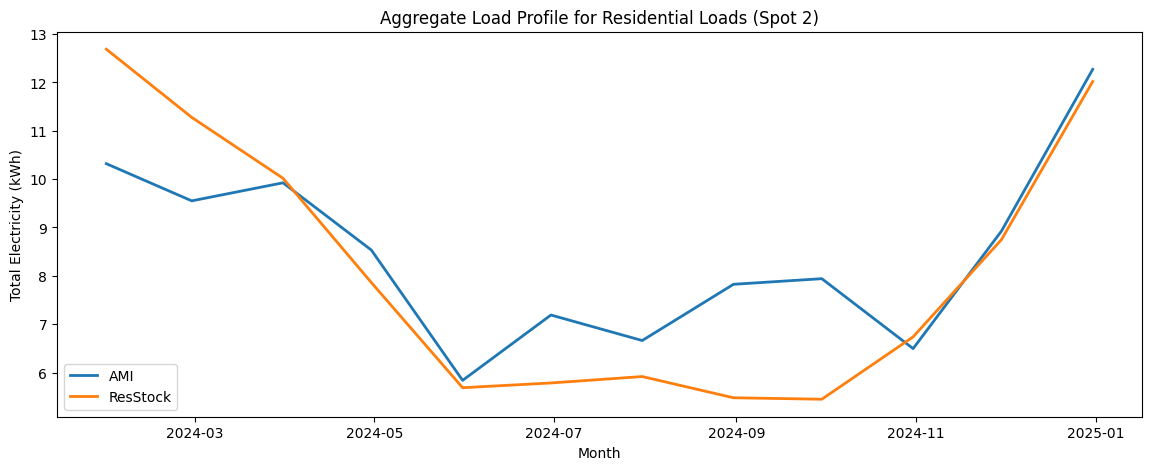

/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_93367/455177160.py:214: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cvrmse_within_month)
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_93367/455177160.py:230: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hourly_cvrmse_by_month, monthly_cvrmse_by_month],


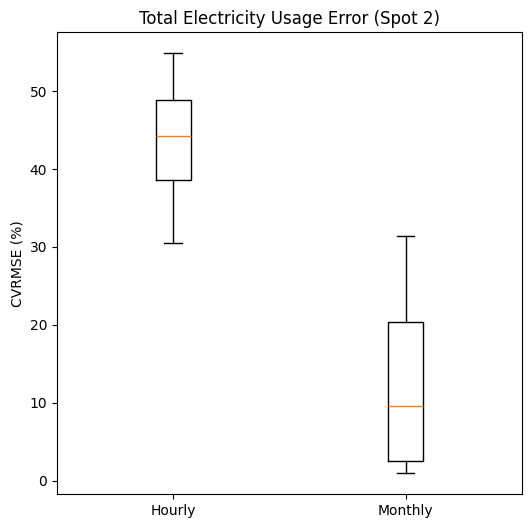

/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_93367/455177160.py:248: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(peak_data, labels=peak_labels, showfliers=False)


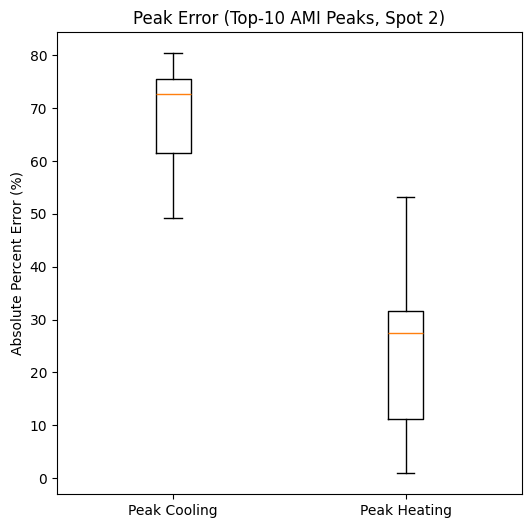

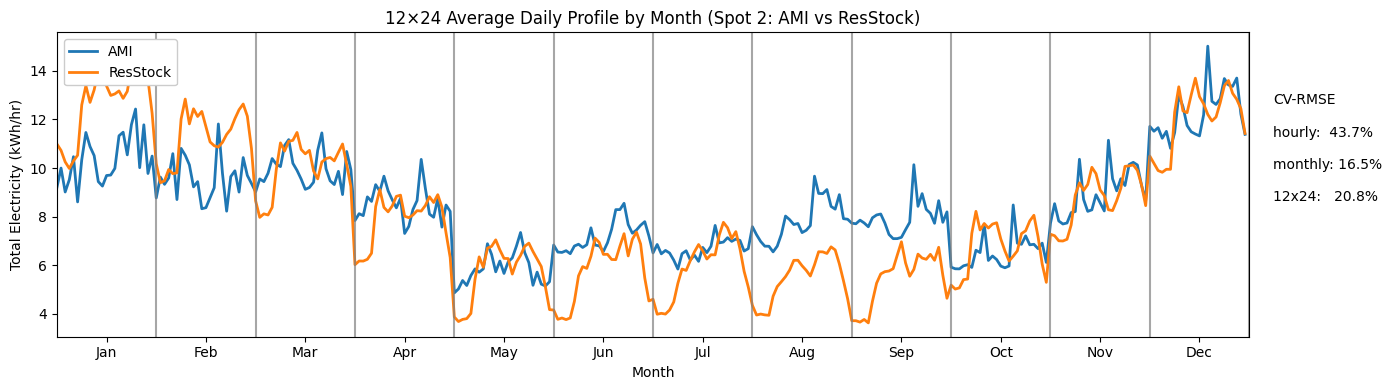


--- Metric Results (Spot 2) ---
Hourly CVRMSE: 43.7%
Monthly CVRMSE: 16.5%
12×24 CVRMSE (month×hour shape): 20.8%

--- Peak Errors (Top-10) as ABS % Error (Spot 2) ---
Peak Heating Error (Top-10 avg abs %): 25.97%
Peak Cooling Error (Top-10 avg abs %): 68.96%


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FULL SPOT 2 PIPELINE (END-TO-END)
# 1) Build ami_agg_2 from df_ami + spot_2 IDs
# 2) Build res_agg_2 from df_resstock + AMI fallback for missing ResStock IDs
# 3) Build spot_2_agg = merge(res_agg_2, ami_agg_2)
# 4) Run metrics + plots on SPOT 2
# ============================================================

# -----------------------------
# SETTINGS
# -----------------------------
TS_COL = "ENDTIME_EST"
TOP_N = 10
EPS = 1e-6

SEASON_MONTHS = {
    "heating": [1, 2, 3, 4, 11, 12],
    "cooling": [5, 6, 7, 8, 9, 10],
}

# ============================================================
# 0) Ensure datetime in both dfs
# ============================================================
df_resstock[TS_COL] = pd.to_datetime(df_resstock[TS_COL], errors="coerce")
df_ami[TS_COL]      = pd.to_datetime(df_ami[TS_COL], errors="coerce")
df_resstock = df_resstock.dropna(subset=[TS_COL])
df_ami      = df_ami.dropna(subset=[TS_COL])

# ============================================================
# 1) AMI AGGREGATE FOR SPOT 2  -> ami_agg_2
# ============================================================
spot_2_ids = set(df_node_2["Spot Number"].dropna().astype(str))

ami_cols_2 = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in spot_2_ids
]

ami_agg_2 = df_ami[[TS_COL]].copy()
ami_agg_2["ami_agg_2"] = df_ami[ami_cols_2].sum(axis=1) if len(ami_cols_2) else 0.0

print("\nami_agg_2.head():")
print(ami_agg_2.head())
print("AMI: #spot_2 IDs:", len(spot_2_ids))
print("AMI: #matched columns:", len(ami_cols_2))

matched_ids_ami = {c.split("_")[0] for c in ami_cols_2}
missing_ids_ami = spot_2_ids - matched_ids_ami
print("AMI: IDs missing in df_ami:")
print(sorted(missing_ids_ami))

# ============================================================
# 2) RESSTOCK AGGREGATE FOR SPOT 2 WITH AMI FALLBACK -> res_agg_2
#    (If an ID missing in ResStock, sum its AMI columns instead.)
# ============================================================
res_ids_available = {c.split("_")[0] for c in df_resstock.columns if c != TS_COL}

ids_from_resstock = sorted([bid for bid in spot_2_ids if bid in res_ids_available])
ids_missing_res   = sorted([bid for bid in spot_2_ids if bid not in res_ids_available])

res_cols_2 = [
    c for c in df_resstock.columns
    if c != TS_COL and c.split("_")[0] in ids_from_resstock
]

ami_cols_for_missing = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in set(ids_missing_res)
]
ids_from_ami_fallback = sorted({c.split("_")[0] for c in ami_cols_for_missing})

ids_missing_both = sorted(set(ids_missing_res) - set(ids_from_ami_fallback))
spot_2_ids_used  = sorted(set(spot_2_ids) - set(ids_missing_both))

print("\nSpot_2 IDs used (after removing missing-in-both IDs):")
print(spot_2_ids_used)

print("\nIDs pulled from ResStock:")
print(ids_from_resstock)

print("\nIDs pulled from AMI (fallback for missing ResStock):")
print(ids_from_ami_fallback)

print("\nIDs missing in BOTH ResStock and AMI (dropped):")
print(ids_missing_both)

print("\n--- FINAL SOURCE SUMMARY ---")
for bid in spot_2_ids_used:
    print(f"{bid}: {'ResStock' if bid in ids_from_resstock else 'AMI fallback'}")

res_part = df_resstock[[TS_COL]].copy()
res_part["res_sum"] = df_resstock[res_cols_2].sum(axis=1) if len(res_cols_2) else 0.0

ami_part = df_ami[[TS_COL]].copy()
ami_part["ami_fallback_sum"] = df_ami[ami_cols_for_missing].sum(axis=1) if len(ami_cols_for_missing) else 0.0

res_agg_2 = res_part.merge(ami_part, on=TS_COL, how="left")
res_agg_2["ami_fallback_sum"] = res_agg_2["ami_fallback_sum"].fillna(0.0)
res_agg_2["res_agg_2"] = res_agg_2["res_sum"] + res_agg_2["ami_fallback_sum"]
res_agg_2 = res_agg_2[[TS_COL, "res_agg_2"]].sort_values(TS_COL)

print("\nres_agg_2.head():")
print(res_agg_2.head())

print("\nAMI columns used for fallback (missing ResStock IDs):")
print(ami_cols_for_missing)

# ============================================================
# 3) BUILD spot_2_agg (THIS IS WHAT YOU WERE MISSING)
# ============================================================
spot_2_agg = res_agg_2.merge(
    ami_agg_2[[TS_COL, "ami_agg_2"]],
    on=TS_COL,
    how="inner"
).sort_values(TS_COL)

print("\nspot_2_agg.head():")
print(spot_2_agg.head())
print("Aligned rows:", len(spot_2_agg))

# ============================================================
# 4) METRICS + PLOTS FOR SPOT 2
# ============================================================
AMI_COL = "ami_agg_2"
RES_COL = "res_agg_2"

df = spot_2_agg[[TS_COL, AMI_COL, RES_COL]].copy()
df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")
df = df.dropna(subset=[TS_COL])

hourly = (
    df.set_index(TS_COL)[[AMI_COL, RES_COL]]
      .resample("H")
      .sum()
      .reset_index()
)

hourly["month"] = hourly[TS_COL].dt.month
hourly["hod"] = hourly[TS_COL].dt.hour
hourly["error_kwh"] = hourly[RES_COL] - hourly[AMI_COL]
hourly["abs_error_kwh"] = hourly["error_kwh"].abs()
hourly["abs_pct_error"] = np.abs(hourly["error_kwh"]) / np.maximum(hourly[AMI_COL], EPS) * 100

def cvrmse(modeled: np.ndarray, known: np.ndarray, eps: float = EPS) -> float:
    modeled = np.asarray(modeled, dtype=float)
    known = np.asarray(known, dtype=float)
    rmse = float(np.sqrt(np.mean((modeled - known) ** 2)))
    denom = float(np.mean(known))
    return np.nan if denom <= eps else rmse / denom

hourly_cvrmse = cvrmse(hourly[RES_COL].to_numpy(), hourly[AMI_COL].to_numpy()) * 100

monthly_totals = (
    hourly.set_index(TS_COL)[[AMI_COL, RES_COL]]
          .resample("M")
          .sum()
          .reset_index()
)
monthly_cvrmse = cvrmse(monthly_totals[RES_COL].to_numpy(), monthly_totals[AMI_COL].to_numpy()) * 100

shape_12x24 = (
    hourly.groupby(["month", "hod"])[[AMI_COL, RES_COL]]
          .mean()
          .reset_index()
          .sort_values(["month", "hod"])
)
cvrmse_12x24 = cvrmse(shape_12x24[RES_COL].to_numpy(), shape_12x24[AMI_COL].to_numpy()) * 100

def peak_top10_abs_pct_error(hourly_df: pd.DataFrame, months: list[int], top_n: int = TOP_N):
    season_df = hourly_df[hourly_df["month"].isin(months)].copy()
    if len(season_df) == 0:
        return np.nan, pd.DataFrame()

    top = season_df.nlargest(top_n, AMI_COL).copy()
    top["abs_pct_error"] = np.abs(top[RES_COL] - top[AMI_COL]) / np.maximum(top[AMI_COL], EPS) * 100
    avg_abs_pct = float(top["abs_pct_error"].mean())

    table = top[[TS_COL, AMI_COL, RES_COL]].copy()
    table["abs_pct_error"] = top["abs_pct_error"]
    table["abs_error_kwh"] = np.abs(top[RES_COL] - top[AMI_COL])

    return avg_abs_pct, table

peak_htg_abs_pct, top10_heating_table = peak_top10_abs_pct_error(hourly, SEASON_MONTHS["heating"], TOP_N)
peak_clg_abs_pct, top10_cooling_table = peak_top10_abs_pct_error(hourly, SEASON_MONTHS["cooling"], TOP_N)

# ---- Plot A: monthly mean profile ----
monthly_profile = (
    hourly.set_index(TS_COL)[[AMI_COL, RES_COL]]
          .resample("M")
          .mean()
          .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_profile[TS_COL], monthly_profile[AMI_COL], label="AMI", linewidth=2)
plt.plot(monthly_profile[TS_COL], monthly_profile[RES_COL], label="ResStock", linewidth=2)
plt.ylabel("Total Electricity (kWh)")
plt.xlabel("Month")
plt.title("Aggregate Load Profile for Residential Loads (Spot 2)")
plt.legend()
plt.show()

# ---- Plot B: CVRMSE boxplot ----
def cvrmse_within_month(g: pd.DataFrame) -> float:
    return cvrmse(g[RES_COL].to_numpy(), g[AMI_COL].to_numpy()) * 100

hourly_cvrmse_by_month = (
    hourly.groupby("month")
          .apply(cvrmse_within_month)
          .dropna()
          .to_numpy(dtype=float)
)

monthly_cvrmse_by_month = []
for m in range(1, 13):
    row = monthly_totals[monthly_totals[TS_COL].dt.month == m]
    if len(row) == 1:
        denom = float(row[AMI_COL].iloc[0])
        err = float((row[RES_COL] - row[AMI_COL]).iloc[0])
        monthly_cvrmse_by_month.append(np.nan if denom <= EPS else abs(err) / denom * 100)

monthly_cvrmse_by_month = np.asarray([v for v in monthly_cvrmse_by_month if np.isfinite(v)], dtype=float)

plt.figure(figsize=(6, 6))
plt.boxplot([hourly_cvrmse_by_month, monthly_cvrmse_by_month],
            labels=["Hourly", "Monthly"], showfliers=False)
plt.ylabel("CVRMSE (%)")
plt.title("Total Electricity Usage Error (Spot 2)")
plt.show()

# ---- Plot C: peak abs % error ----
peak_clg_pct = top10_cooling_table["abs_pct_error"].to_numpy(dtype=float) if len(top10_cooling_table) else np.array([])
peak_htg_pct = top10_heating_table["abs_pct_error"].to_numpy(dtype=float) if len(top10_heating_table) else np.array([])

peak_data, peak_labels = [], []
if len(peak_clg_pct) > 0:
    peak_data.append(peak_clg_pct); peak_labels.append("Peak Cooling")
if len(peak_htg_pct) > 0:
    peak_data.append(peak_htg_pct); peak_labels.append("Peak Heating")

if len(peak_data) > 0:
    plt.figure(figsize=(6, 6))
    plt.boxplot(peak_data, labels=peak_labels, showfliers=False)
    plt.ylabel("Absolute Percent Error (%)")
    plt.title(f"Peak Error (Top-{TOP_N} AMI Peaks, Spot 2)")
    plt.show()

# ---- Plot D: 12x24 by month ----
shape_12x24 = shape_12x24.copy()
shape_12x24["mh_idx"] = (shape_12x24["month"] - 1) * 24 + shape_12x24["hod"]

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_tick_pos = [24 * (i + 0.5) for i in range(12)]

plt.figure(figsize=(14, 4))
plt.plot(shape_12x24["mh_idx"], shape_12x24[AMI_COL], label="AMI", linewidth=2)
plt.plot(shape_12x24["mh_idx"], shape_12x24[RES_COL], label="ResStock", linewidth=2)
for k in range(13):
    plt.axvline(x=24 * k, color="gray", linestyle="-", alpha=0.7)
plt.xlim(0, 12 * 24)
plt.xticks(month_tick_pos, MONTH_NAMES)
plt.xlabel("Month")
plt.ylabel("Total Electricity (kWh/hr)")
plt.title("12×24 Average Daily Profile by Month (Spot 2: AMI vs ResStock)")
plt.legend(loc="upper left", framealpha=1)

txt = (
    "CV-RMSE\n\n"
    f"hourly:  {hourly_cvrmse:.1f}%\n\n"
    f"monthly: {monthly_cvrmse:.1f}%\n\n"
    f"12x24:   {cvrmse_12x24:.1f}%"
)
plt.gca().text(1.02, 0.80, txt, transform=plt.gca().transAxes, ha="left", va="top")
plt.tight_layout()
plt.show()

print("\n--- Metric Results (Spot 2) ---")
print(f"Hourly CVRMSE: {hourly_cvrmse:.1f}%")
print(f"Monthly CVRMSE: {monthly_cvrmse:.1f}%")
print(f"12×24 CVRMSE (month×hour shape): {cvrmse_12x24:.1f}%")

print(f"\n--- Peak Errors (Top-{TOP_N}) as ABS % Error (Spot 2) ---")
print(f"Peak Heating Error (Top-{TOP_N} avg abs %): {peak_htg_abs_pct:.2f}%")
print(f"Peak Cooling Error (Top-{TOP_N} avg abs %): {peak_clg_abs_pct:.2f}%")


# NODE 3

In [12]:
node_3 = results_folder / "Branch3-spotload.xlsx"
df_node_3 = pd.read_excel(node_3)
print(df_node_3.head())


   Network Id    Section Id    Spot Number Phase    Spot Type  \
0     4301002   220269829-L  220269829-L-2   NaN        Other   
1     4301002  220269829-L1      220269829     A        Mixed   
2     4301002   310059674-L      310059674     A  Residential   
3     4301002   220529452-L      220529452     A  Residential   
4     4301002   220268252-L      220268252     A  Residential   

   Spot kVA A\n(kVA)  Spot kVA B\n(kVA)  Spot kVA C\n(kVA)  \
0           0.000000                  0                NaN   
1           0.000000                  0                NaN   
2           5.426999                  0                NaN   
3           6.040350                  0                NaN   
4           3.645173                  0                NaN   

   Spot Tot kVA\n(kVA)  Spot PF A\n(%)  ...  Spot kWh C\n(kWh)  \
0             0.000000        0.000000  ...                NaN   
1             0.000000        0.000000  ...                NaN   
2             5.426999       91.463502

In [ ]:
# Find and aggregate resstock loads for spot 3

import pandas as pd

TS_COL = "ENDTIME_EST"

# Spot 3 building IDs (change spot_3 to whatever holds Spot 3 IDs)
spot_3_ids = set(spot_3.astype(str))

# ResStock columns for spot_3
res_cols_3 = [
    c for c in df_resstock.columns
    if c != TS_COL and c.split("_")[0] in spot_3_ids
]

# Aggregate ResStock
res_agg_3 = df_resstock[[TS_COL]].copy()
res_agg_3["res_agg_3"] = df_resstock[res_cols_3].sum(axis=1) if len(res_cols_3) else 0.0

print(res_agg_3.head())

print("Number of spot_3 IDs:", len(spot_3_ids))
print("Number of matched df_resstock columns:", len(res_cols_3))

matched_ids = {c.split("_")[0] for c in res_cols_3}
missing_ids = spot_3_ids - matched_ids

print("\nMissing building IDs (in spot_3 but not in df_resstock):")
print(sorted(missing_ids))


In [ ]:
## RESSTOCK AGGREGATION
import pandas as pd

TS_COL = "ENDTIME_EST"

# ============================
# Spot 1: ResStock + AMI fallback
# ============================
SPOT_NAME = "spot_1"
OUT_COL   = "res_agg_1"

# --- 0) FORCE SAME DATETIME TYPE IN BOTH DFS ---
df_resstock[TS_COL] = pd.to_datetime(df_resstock[TS_COL], errors="coerce")
df_ami[TS_COL]      = pd.to_datetime(df_ami[TS_COL], errors="coerce")
df_resstock = df_resstock.dropna(subset=[TS_COL])
df_ami      = df_ami.dropna(subset=[TS_COL])

# --- 1) SPOT 1 IDS ---
spot_1_ids = sorted({str(x) for x in spot_1.dropna().unique()})

# --- 2) RESSTOCK: IDs available + columns to use ---
res_ids_available = {c.split("_")[0] for c in df_resstock.columns if c != TS_COL}
ids_from_resstock = sorted([bid for bid in spot_1_ids if bid in res_ids_available])
ids_missing_res   = sorted([bid for bid in spot_1_ids if bid not in res_ids_available])

res_cols_1 = [
    c for c in df_resstock.columns
    if c != TS_COL and c.split("_")[0] in ids_from_resstock
]

# --- 3) AMI: columns to use for missing IDs (match by bid prefix) ---
ami_cols_for_missing = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in ids_missing_res
]
ids_from_ami = sorted({c.split("_")[0] for c in ami_cols_for_missing})

# IDs missing in both (drop)
ids_missing_both = sorted(set(ids_missing_res) - set(ids_from_ami))
spot_1_ids_used  = sorted(set(spot_1_ids) - set(ids_missing_both))

# --- 4) PRINTS ---
print(f"\n{SPOT_NAME} IDs used (after removing missing-in-both IDs):")
print(spot_1_ids_used)

print("\nIDs pulled from ResStock:")
print(ids_from_resstock)

print("\nIDs pulled from AMI (fallback for missing ResStock):")
print(ids_from_ami)

print("\nIDs missing in BOTH ResStock and AMI (dropped):")
print(ids_missing_both)

print("\n--- FINAL SOURCE SUMMARY ---")
for bid in spot_1_ids_used:
    print(f"{bid}: {'ResStock' if bid in ids_from_resstock else 'AMI fallback'}")

# --- 5) AGGREGATE RESSTOCK + AMI FALLBACK ---
res_part = df_resstock[[TS_COL]].copy()
res_part["res_sum"] = df_resstock[res_cols_1].sum(axis=1) if len(res_cols_1) else 0.0

ami_part = df_ami[[TS_COL]].copy()
ami_part["ami_fallback_sum"] = df_ami[ami_cols_for_missing].sum(axis=1) if len(ami_cols_for_missing) else 0.0

res_agg_1 = res_part.merge(ami_part, on=TS_COL, how="left")
res_agg_1["ami_fallback_sum"] = res_agg_1["ami_fallback_sum"].fillna(0.0)
res_agg_1[OUT_COL] = res_agg_1["res_sum"] + res_agg_1["ami_fallback_sum"]
res_agg_1 = res_agg_1[[TS_COL, OUT_COL]]

print("\nres_agg_1.head():")
print(res_agg_1.head())

print("\nAMI columns used for fallback:")
print(ami_cols_for_missing)


In [ ]:
# AMI AGGREGATION
import pandas as pd

TS_COL = "ENDTIME_EST"

# ============================
# AMI spot_1: find cols, aggregate, matches/mismatches
# ============================

# 1) Spot 1 IDs as a SET
spot_1 = df_node_1["Spot Number"]          # <-- change if your column name differs
spot_1_ids = set(spot_1.dropna().astype(str))

# 2) AMI columns that belong to spot_1 (match by building-id prefix before "_")
ami_cols_1 = [
    c for c in df_ami.columns
    if c != TS_COL and c.split("_")[0] in spot_1_ids
]

# 3) Aggregate AMI for spot_1
ami_agg_1 = df_ami[[TS_COL]].copy()
ami_agg_1[TS_COL] = pd.to_datetime(ami_agg_1[TS_COL], errors="coerce")
ami_agg_1["ami_agg_1"] = df_ami[ami_cols_1].sum(axis=1) if len(ami_cols_1) else 0.0

print(ami_agg_1.head())

# 4) Lengths + match/mismatch lists
print("Number of spot_1 IDs:", len(spot_1_ids))
print("Number of matched df_ami columns:", len(ami_cols_1))

matched_ids_1 = {c.split("_")[0] for c in ami_cols_1}
missing_ids_1 = spot_1_ids - matched_ids_1

print("\nMatched building IDs (spot_1):")
print(sorted(matched_ids_1))

print("\nMissing building IDs (in spot_1 but not in df_ami):")
print(sorted(missing_ids_1))

# ============================
# Merge with ResStock aggregate (spot_1)
# ============================

res_agg_1 = res_agg_1.copy()
res_agg_1[TS_COL] = pd.to_datetime(res_agg_1[TS_COL], errors="coerce")

spot_1_agg = (
    res_agg_1.merge(ami_agg_1[[TS_COL, "ami_agg_1"]], on=TS_COL, how="inner")
             .sort_values(TS_COL)
)

print("\nspot_1_agg head():")
print(spot_1_agg.head())
print("Aligned rows:", len(spot_1_agg))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SIMPLE, HUMAN-READABLE AMI vs ResStock METRICS + PLOTS
# - Peaks reported as ABSOLUTE PERCENT ERROR (%)
# - Plot labels: "AMI" and "ResStock"
# - Automatically saves PNGs
# ============================================================

# -----------------------------
# SETTINGS
# -----------------------------
TS_COL = "ENDTIME_EST"
AMI_COL = "ami_agg_1"     # measured
RES_COL = "res_agg_1"     # modeled

TOP_N = 10
EPS = 1e-6
PREFIX = "spot_1"

SEASON_MONTHS = {
    "heating": [1, 2, 3, 4, 11, 12],
    "cooling": [5, 6, 7, 8, 9, 10],
}

# -----------------------------
# OUTPUT DIRECTORY + SAVE HELPER
# -----------------------------
OUTDIR = Path("figures_resstock_vs_ami")
OUTDIR.mkdir(parents=True, exist_ok=True)
current_path = Path(os.getcwd())
results_folder = current_path / ".." / "results"
def save_current_fig(name: str, dpi: int = 300):
    path = results_folder / f"{name}.png"
    plt.gcf().savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path.resolve()}")

# -----------------------------
# 0) Make hourly dataframe
# -----------------------------
df = spot_1_agg[[TS_COL, AMI_COL, RES_COL]].copy()
df[TS_COL] = pd.to_datetime(df[TS_COL])

hourly = (
    df.set_index(TS_COL)[[AMI_COL, RES_COL]]
      .resample("H")
      .sum()
      .reset_index()
)

hourly["month"] = hourly[TS_COL].dt.month
hourly["hod"] = hourly[TS_COL].dt.hour
hourly["error_kwh"] = hourly[RES_COL] - hourly[AMI_COL]
hourly["abs_error_kwh"] = hourly["error_kwh"].abs()
hourly["abs_pct_error"] = (
    np.abs(hourly["error_kwh"]) / np.maximum(hourly[AMI_COL], EPS) * 100
)

# -----------------------------
# 1) CVRMSE
# -----------------------------
def cvrmse(modeled, known, eps=EPS):
    modeled = np.asarray(modeled, dtype=float)
    known = np.asarray(known, dtype=float)
    rmse = np.sqrt(np.mean((modeled - known) ** 2))
    denom = np.mean(known)
    return np.nan if denom <= eps else rmse / denom

hourly_cvrmse = cvrmse(hourly[RES_COL], hourly[AMI_COL]) * 100

monthly_totals = (
    hourly.set_index(TS_COL)[[AMI_COL, RES_COL]]
          .resample("M")
          .sum()
          .reset_index()
)
monthly_cvrmse = cvrmse(monthly_totals[RES_COL], monthly_totals[AMI_COL]) * 100

shape_12x24 = (
    hourly.groupby(["month", "hod"])[[AMI_COL, RES_COL]]
          .mean()
          .reset_index()
          .sort_values(["month", "hod"])
)
cvrmse_12x24 = cvrmse(shape_12x24[RES_COL], shape_12x24[AMI_COL]) * 100

# -----------------------------
# 2) Peak ABS % error (Top-N AMI)
# -----------------------------
def avangrid_peak_top10_abs_pct_error(hourly_df, months, top_n=TOP_N):
    season_df = hourly_df[hourly_df["month"].isin(months)]
    if len(season_df) == 0:
        return np.nan, pd.DataFrame()

    top = season_df.nlargest(top_n, AMI_COL).copy()
    top["abs_pct_error"] = (
        np.abs(top[RES_COL] - top[AMI_COL]) / np.maximum(top[AMI_COL], EPS) * 100
    )

    table = top[[TS_COL, AMI_COL, RES_COL]].copy()
    table["abs_pct_error"] = top["abs_pct_error"]
    table["abs_error_kwh"] = np.abs(top[RES_COL] - top[AMI_COL])

    return float(top["abs_pct_error"].mean()), table

peak_htg_abs_pct, top10_heating_table = avangrid_peak_top10_abs_pct_error(
    hourly, SEASON_MONTHS["heating"]
)
peak_clg_abs_pct, top10_cooling_table = avangrid_peak_top10_abs_pct_error(
    hourly, SEASON_MONTHS["cooling"]
)

# -----------------------------
# 3) PLOTS
# -----------------------------

# A) Monthly aggregate profile
monthly_profile = (
    hourly.set_index(TS_COL)[[AMI_COL, RES_COL]]
          .resample("M")
          .mean()
          .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_profile[TS_COL], monthly_profile[AMI_COL], label="AMI", linewidth=2)
plt.plot(monthly_profile[TS_COL], monthly_profile[RES_COL], label="ResStock", linewidth=2)
plt.ylabel("Total Electricity (kWh)")
plt.xlabel("Month")
plt.title("Aggregate Load Profile for Residential Loads")
plt.legend()

save_current_fig(f"{PREFIX}_A_monthly_profile")
plt.show()

# B) CVRMSE boxplot
def cvrmse_within_month(g):
    return cvrmse(g[RES_COL], g[AMI_COL]) * 100

hourly_cvrmse_by_month = (
    hourly.groupby("month")
          .apply(cvrmse_within_month)
          .dropna()
          .to_numpy()
)

monthly_cvrmse_by_month = []
for m in range(1, 13):
    row = monthly_totals[monthly_totals[TS_COL].dt.month == m]
    if len(row) == 1:
        denom = row[AMI_COL].iloc[0]
        err = row[RES_COL].iloc[0] - denom
        if denom > EPS:
            monthly_cvrmse_by_month.append(abs(err) / denom * 100)

plt.figure(figsize=(6, 6))
plt.boxplot(
    [hourly_cvrmse_by_month, monthly_cvrmse_by_month],
    labels=["Hourly", "Monthly"],
    showfliers=False
)
plt.ylabel("CVRMSE (%)")
plt.title("Total Electricity Usage Error")

save_current_fig(f"{PREFIX}_B_cvrmse_boxplot")
plt.show()

# C) Peak ABS % error boxplot
peak_data, peak_labels = [], []
if len(top10_cooling_table):
    peak_data.append(top10_cooling_table["abs_pct_error"])
    peak_labels.append("Peak Cooling")
if len(top10_heating_table):
    peak_data.append(top10_heating_table["abs_pct_error"])
    peak_labels.append("Peak Heating")

if peak_data:
    plt.figure(figsize=(6, 6))
    plt.boxplot(peak_data, labels=peak_labels, showfliers=False)
    plt.ylabel("Absolute Percent Error (%)")
    plt.title(f"Peak Error (Top-{TOP_N} AMI Peaks)")

    save_current_fig(f"{PREFIX}_C_peak_error_boxplot")
    plt.show()

# D) 12×24 shape plot
shape_12x24["mh_idx"] = (shape_12x24["month"] - 1) * 24 + shape_12x24["hod"]

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_tick_pos = [24 * (i + 0.5) for i in range(12)]

plt.figure(figsize=(14, 4))
plt.plot(shape_12x24["mh_idx"], shape_12x24[AMI_COL], label="AMI", linewidth=2)
plt.plot(shape_12x24["mh_idx"], shape_12x24[RES_COL], label="ResStock", linewidth=2)

for k in range(13):
    plt.axvline(x=24 * k, color="gray", alpha=0.7)

plt.xlim(0, 12 * 24)
plt.xticks(month_tick_pos, MONTH_NAMES)
plt.xlabel("Month")
plt.ylabel("Total Electricity (kWh/hr)")
plt.title("12×24 Average Daily Profile by Month (AMI vs ResStock)")
plt.legend(loc="upper left")

plt.gca().text(
    1.02, 0.80,
    f"CVRMSE\n\nhourly:  {hourly_cvrmse:.1f}%\n\nmonthly: {monthly_cvrmse:.1f}%\n\n12x24:   {cvrmse_12x24:.1f}%",
    transform=plt.gca().transAxes,
    ha="left", va="top"
)

plt.tight_layout()
save_current_fig(f"{PREFIX}_D_12x24_shape")
plt.show()

# -----------------------------
# 4) PRINT METRICS
# -----------------------------
print("\n--- Metric Results ---")
print(f"Hourly CVRMSE: {hourly_cvrmse:.1f}%")
print(f"Monthly CVRMSE: {monthly_cvrmse:.1f}%")
print(f"12×24 CVRMSE: {cvrmse_12x24:.1f}%")

print(f"\n--- Peak ABS % Error (Top-{TOP_N}) ---")
print(f"Heating: {peak_htg_abs_pct:.2f}%")
print(f"Cooling: {peak_clg_abs_pct:.2f}%")
